In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

In [5]:
sys.path.append(".")

In [6]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs.base_db import BaseDB
from utils.dbs.qlever import QleverDB
from utils.dbs.fuseki import FusekiDB
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

2026-03-27 15:56:19,904 - INFO - Loading faiss.
2026-03-27 15:56:19,952 - INFO - Successfully loaded faiss.


In [7]:
powers = np.arange(0, 4)  # extend on a more powerful machine
sizes = 10**powers

In [8]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-03-27 15:56:20,054 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-03-27 15:56:20,055 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-03-27 15:56:20,055 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-03-27 15:56:20,056 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...


In [9]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode_streaming(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [10]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -0.0051073539070785046, 0.09506018459796906, -0.02917008101940155, -0.07172351330518723, 0.03642679378390312, 0.017889918759465218, 0.0777449756860733, -0.010582818649709225, -0.027199456468224525, -0.014839813113212585, 0.004996409639716148, -0.05195300653576851, -0.01563340052962303, -0.0004883771180175245, 0.012572054751217365, -0.0434229

In [12]:
base_bsbm_set = datasets[2]

db_fuseki = FusekiDB(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_qlever = QleverDB(
    id="test_qlever",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)


In [13]:
import os
os.getcwd()

'/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks'

In [14]:
import time

import pandas as pd
def test_db_query(db_tested: BaseDB, test_tensor: DataTensor):
    with db_tested:
        timings = []
        stats = pd.DataFrame()
        db_tested.start_record_stats()
        for _ in tqdm.tqdm(range(128)):
            start_time = time.time()
            noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
            noised_tensor = DataTensor.from_numpy(noised_tensor)

            results = db_tested.query_auto(
                noised_tensor,
                query_difficulty=QUERY_DIFFICULTY.EASY,
                query_type=QUERY_TYPE.EMBEDDED,
            )
            elapsed_time = time.time() - start_time
            timings.append(elapsed_time)
        db_tested.stop_record_stats()
        stats = db_tested.get_stats()

    print("Median elapsed time:", np.median(timings))
    print("Stats:", stats)
test_db_query(db_fuseki, test_tensor)
test_db_query(db_qlever, test_tensor)

2026-03-27 15:56:20,737 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-03-27 15:56:25,282 - INFO - Stopping server with container name fuseki_benchmarks_test_fuseki
2026-03-27 15:56:25,323 - ERROR - Command failed with return code 1
2026-03-27 15:56:25,349 - INFO - Starting Fuseki server with container name fuseki_benchmarks_test_fuseki on port 3030
2026-03-27 15:56:25,370 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 61] Connection refused> (http://localhost:3030/test_fuseki/sparql)
2026-03-27 15:56:26,496 - INFO - Server is up and responding to queries
100%|██████████| 128/128 [00:06<00:00, 18.29it/s]
2026-03-27 15:56:33,563 - INFO - Stopping server with container name fuseki_benchmarks_test_fuseki
2026-03-27 15:56:34,440 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-27 15:56:34,442 - INFO - Running command to create index: qlever-index -f data/bsbm_2/dataset_encoded.nt -i test_qlever -m 8G


Median elapsed time: 0.03758597373962402
Stats:                     timestamp cpu_percent       mem_usage     net_io  \
0  2026-03-27 15:56:27.534677      247.58     270952038.4    14000.0   
1  2026-03-27 15:56:29.539027      218.12     545574092.8   335000.0   
2  2026-03-27 15:56:31.552513      139.77    1019845017.6   889000.0   
3  2026-03-27 15:56:33.562343      159.98  1227286904.832  1420000.0   

   block_io pids  
0  557000.0   57  
1  963000.0   68  
2  963000.0   67  
3  963000.0   67  


2026-03-27 15:56:38,401 - INFO - Stopping server with container name qlever_benchmarks_test_qlever
2026-03-27 15:56:38,448 - ERROR - Command failed with return code 1
2026-03-27 15:56:38,487 - INFO - Starting QLever server with container name qlever_benchmarks_test_qlever on port 5030
2026-03-27 15:56:38,489 - INFO - Running command: docker run --name qlever_benchmarks_test_qlever -e UID=501 -e GID=220 -p 5030:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_2/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i test_qlever --port 5030 -k 0'
2026-03-27 15:56:38,502 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 61] Connection refused> (http://localhost:5030/test_qlever/sparql)
2026-03-27 15:56:39,507 - INFO - Waiting for server to start..., got error: [Errno 54] Connection reset by peer (http://localhost:5030/test_qlever/sparql)
2026-03-27 15:56:40,512 - INFO - Waiting for server to start..., got error: [E

Median elapsed time: 0.0316544771194458
Stats:                     timestamp cpu_percent    mem_usage     net_io block_io  \
0  2026-03-27 15:56:43.274079       81.43  118384230.4   580000.0      0.0   
1  2026-03-27 15:56:45.277250       85.29  120271667.2  1270000.0      0.0   
2  2026-03-27 15:56:47.289872         0.0  120166809.6  1420000.0      0.0   

  pids  
0   28  
1   28  
2   27  


In [15]:
import os
os.environ["PATH"]

'/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/bin:/opt/homebrew/opt/icu4c@78/sbin:/opt/homebrew/opt/icu4c@78/bin:/opt/homebrew/Caskroom/miniconda/base/bin:/opt/homebrew/Caskroom/miniconda/base/bin:/opt/homebrew/Caskroom/miniconda/base/condabin:/Users/benedikt/.nvm/versions/node/v22.12.0/bin:/opt/homebrew/opt/openjdk@25/bin:/Users/benedikt/java/jdk8u362-b09/Contents/Home/bin:/opt/homebrew/bin:/opt/homebrew/sbin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/X11/bin:/Library/Apple/usr/bin:/Library/TeX/texbin:/Applications/Wireshark.app/Contents/MacOS:/Applications/nmap.app/Contents/Resources/bin:/Applications/ncat.app/Contents/Resources/bin:/Applications/nping.app/Contents/Resources/bin:/Applications/zenmap.app/Conten

## Try some timings!

In [16]:
from dataclasses import dataclass
import timeit
import pandas as pd

from utils.dbs.base_docker import BaseDocker


@dataclass
class TestResult:
    timings: pd.DataFrame
    stats: pd.DataFrame


def test_db(
    power: int,
    size: int,
    db: BaseDocker,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> TestResult:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return TestResult(timings=pd.DataFrame(), stats=pd.DataFrame())
    db.start_record_stats()
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        # add a small amount of noise to the test tensor to avoid caching effects
        noised_tensor = DataTensor.from_numpy(
            test_tensor.data + np.random.normal(scale=0.001, size=test_tensor.shape)
        )

        test_queries = db.get_queries(embedding=noised_tensor)
        q = test_queries[difficulty][query_type]
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    db.stop_record_stats()
    stats = db.stat_recorder.get_stats()
    stats["size"] = encoded_sizes[power]
    stats["power"] = power
    stats["difficulty"] = difficulty.value
    stats["query_type"] = query_type.value
    stats["engine"] = db.name
    db.stat_recorder.clear_stats()

    return TestResult(
        timings=pd.DataFrame(timings),
        stats=stats,
    )


timings_df = pd.DataFrame()
stats_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDocker] = [
        QleverDB(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        FusekiDB(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 128 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_results = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat(
                        [timings_df, db_results.timings], ignore_index=True
                    )
                    stats_df = pd.concat(
                        [stats_df, db_results.stats], ignore_index=True
                    )


2026-03-27 15:56:52,328 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-27 15:56:52,328 - WARNING - DB directory scratch/bsbm/bsbm_0/qlever_db already exists, removing locks if any
2026-03-27 15:56:52,329 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-27 15:56:52,359 - ERROR - Command failed with return code 1
2026-03-27 15:56:52,386 - INFO - Starting QLever server with container name qlever_benchmarks_timing-qlever on port 5030
2026-03-27 15:56:52,388 - INFO - Running command: docker run --name qlever_benchmarks_timing-qlever -e UID=501 -e GID=220 -p 5030:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_0/qlever_db:/data -w /data  qlever:tensors 'qlever-server -o -i timing-qlever --port 5030 -k 0'
2026-03-27 15:56:52,396 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 61] Connection refused> (http://localhost:5030/timing-qlever/sparql)


Running BDSDM timing for size 1...
Testing QLever (Extended) with difficulty easy and query type index...


2026-03-27 15:56:53,401 - INFO - Waiting for server to start..., got error: [Errno 54] Connection reset by peer (http://localhost:5030/timing-qlever/sparql)
2026-03-27 15:56:54,406 - INFO - Waiting for server to start..., got error: [Errno 54] Connection reset by peer (http://localhost:5030/timing-qlever/sparql)
2026-03-27 15:56:55,423 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type index, db QLever (Extended): 100%|██████████| 128/128 [00:00<00:00, 177.24it/s]
2026-03-27 15:56:56,464 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-27 15:56:57,764 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-27 15:56:57,765 - WARNING - DB directory scratch/bsbm/bsbm_0/qlever_db already exists, removing locks if any
2026-03-27 15:56:57,765 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-27 15:56:57,789 - ERROR - Command failed with return code 1
2026

Testing QLever (Extended) with difficulty easy and query type embedded...


2026-03-27 15:56:58,831 - INFO - Waiting for server to start..., got error: [Errno 54] Connection reset by peer (http://localhost:5030/timing-qlever/sparql)
2026-03-27 15:56:59,839 - INFO - Waiting for server to start..., got error: [Errno 54] Connection reset by peer (http://localhost:5030/timing-qlever/sparql)
2026-03-27 15:57:00,856 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db QLever (Extended): 100%|██████████| 128/128 [00:01<00:00, 94.60it/s]
2026-03-27 15:57:02,283 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-27 15:57:03,564 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt


...

2026-03-27 15:58:49,691 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki
2026-03-27 15:58:49,732 - ERROR - Command failed with return code 1
2026-03-27 15:58:49,767 - INFO - Starting Fuseki server with container name fuseki_benchmarks_timing-fuseki on port 3030
2026-03-27 15:58:49,782 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 61] Connection refused> (http://localhost:3030/timing-fuseki/sparql)
2026-03-27 15:58:50,972 - INFO - Server is up and responding to queries
2026-03-27 15:58:50,974 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki


Query type QUERY_TYPE.INDEX not available for FusekiDB + RDFTensor, skipping.


2026-03-27 15:58:51,548 - INFO - Loading dataset into Fuseki server from data/bsbm_3/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-27 15:58:59,892 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki
2026-03-27 15:58:59,925 - ERROR - Command failed with return code 1
2026-03-27 15:58:59,959 - INFO - Starting Fuseki server with container name fuseki_benchmarks_timing-fuseki on port 3030
2026-03-27 15:58:59,974 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 61] Connection refused> (http://localhost:3030/timing-fuseki/sparql)
2026-03-27 15:59:01,099 - INFO - Server is up and responding to queries
Timing for size 1000, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 128/128 [00:23<00:00,  5.42it/s]
2026-03-27 15:59:26,481 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki


In [17]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [18]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type
0,None,0,1,0.039679,0,QLever (Extended),easy,index
1,None,0,1,0.012488,1,QLever (Extended),easy,index
2,None,0,1,0.007654,2,QLever (Extended),easy,index
3,None,0,1,0.008156,3,QLever (Extended),easy,index
4,None,0,1,0.015695,4,QLever (Extended),easy,index
...,...,...,...,...,...,...,...,...
1531,None,3,1000,0.139631,123,FusekiDB + RDFTensor,easy,embedded
1532,None,3,1000,0.205184,124,FusekiDB + RDFTensor,easy,embedded
1533,None,3,1000,0.133996,125,FusekiDB + RDFTensor,easy,embedded
1534,None,3,1000,0.125225,126,FusekiDB + RDFTensor,easy,embedded


In [19]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['QLever (Extended)', 'FusekiDB + RDFTensor']
Length: 2, dtype: str

In [20]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [21]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [22]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever (Extended)': 'C0', 'FusekiDB + RDFTensor': 'C1'}

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_72800/421834132.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


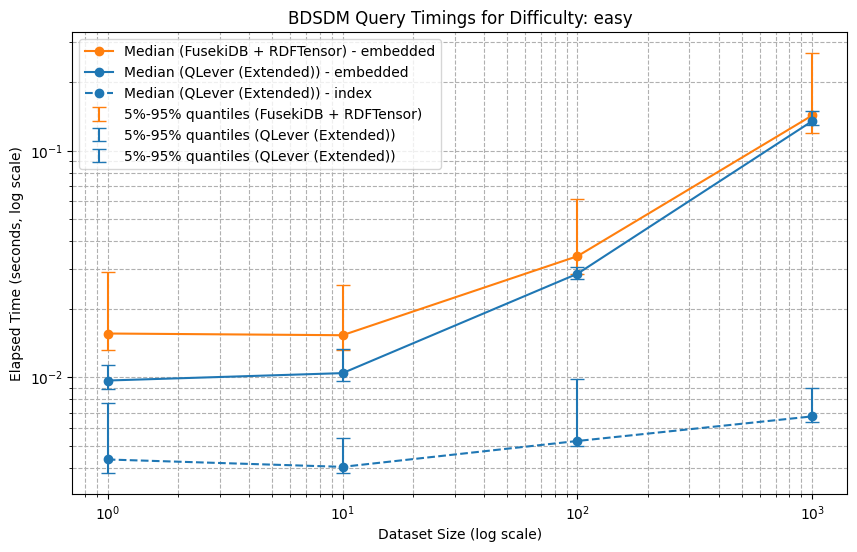

In [23]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()